In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import Basic_functions as bf
from scipy.sparse import hstack, vstack, csr_array, save_npz, load_npz

In [2]:
import sklearn.utils as sku
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import roc_auc_score, roc_curve, log_loss, confusion_matrix, ConfusionMatrixDisplay
import lightgbm as lgbm
from lightgbm import early_stopping
#import optuna as opt

In [2]:
raw = open("Speeches\Aaja_Chemnitz'_tale_ved_den_udvidede_spørgetime_med_statsministeren.txt", "r", encoding="utf-8").read()
text, header = bf.extract_header(raw)

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\jonas\AppData\Local\Temp\ipykernel_8536\254240665.py:1: SyntaxWarning: invalid escape sequence '\A'
  raw = open("Speeches\Aaja_Chemnitz'_tale_ved_den_udvidede_spørgetime_med_statsministeren.txt", "r", encoding="utf-8").read()


In [4]:
chars = "abcdefghijklmnopqrstuvwxyzæøå "
bigons = []
trigons = []
for i in range(len(chars)):
    for j in range(len(chars)):
        bigons.append(chars[i] + chars[j])
for i in range(len(chars)):
    for j in range(len(chars)):
        for k in range(len(chars)):
            trigons.append(chars[i] + chars[j] + chars[k])

In [27]:
raw = open("Speeches/Zenia_Stampes_grundlovstale.txt", "r", encoding="utf-8").read()
text, header = bf.extract_header(raw)
text = text.strip().lower().replace("\n", " ")
header_lines = header.splitlines()

In [3]:
#np.savetxt("words_by_speech.csv", words, delimiter=",", fmt="%s")
#np.savetxt("counts_by_speech.csv", counts, delimiter=",", fmt="%d")
with open("txt_files/words_by_speech.txt", "w", encoding="utf-8") as f:
    for i in range(len(words)):
        for j in range(len(words[i])):
            f.write(words[i][j])
            f.write(", ")
        f.write("\n")
with open("txt_files/counts_by_speech.txt", "w") as f:
    for i in range(len(counts)):
        for j in range(len(counts[i])):
            f.write(str(counts[i][j]))
            f.write(", ")
        f.write("\n")

NameError: name 'words' is not defined

In [38]:
words = np.genfromtxt("txt_files/words_ranked_years.txt", delimiter=", ", dtype=str)

In [4]:
empty_char = [" "]
trigons_filtered = np.genfromtxt("txt_files/trigons_filtered.txt", delimiter="\n", dtype=str)
data_speech, labels_speech = bf.read_files("Speeches", empty_char, sparse=True)

In [ ]:
#np.savetxt("Data_files/labels_speech.txt", labels_speech, delimiter=", ", fmt="%s")

In [ ]:
data_article_05, labels_article_05 = bf.read_files("Articles_05", trigons, sparse=True)
save_npz("Data_files/data_articles_05.npz", data_article_05)
np.savetxt("Data_files/labels_articles_05.txt", labels_article_05, delimiter="; ", fmt="%s")

In [ ]:
#save_npz("Data_files/data_speech.npz", data_speech)
#np.savetxt("Data_files/labels_speech.txt", labels_speech, delimiter=", ", fmt="%s")

In [79]:
data_articles_dict = {}
labels_articles_dict = {}
for i in range(19):
    if (i == 5) or (i == 6):
        continue
    if i < 10:
        data_articles_dict[i] = load_npz(f"Data_files/data_articles_0{i}.npz")
        labels_articles_dict[i] = np.genfromtxt(f"Data_files/labels_articles_0{i}.txt", delimiter="; ", dtype=str)
    else:
        data_articles_dict[i] = load_npz(f"Data_files/data_articles_{i}.npz")
        labels_articles_dict[i] = np.genfromtxt(f"Data_files/labels_articles_{i}.txt", delimiter="; ", dtype=str)

In [80]:
data_articles = vstack([data_articles_dict[i] for i in range(19) if (i != 5) and (i != 6)])
labels_articles = np.concatenate([labels_articles_dict[i] for i in range(19) if (i != 5) and (i != 6)])
data_articles = hstack([labels_articles[:,4].astype(float).reshape(-1, 1), data_articles], format="csr")

In [81]:
#Free the memory used by the dicts
data_articles_dict = None
labels_articles_dict = None

In [82]:
data_speech = load_npz("Data_files/data_speech.npz")
data_speech_nltk = load_npz("tfidf_NLTK_Speeches.npz")
labels_speech = np.genfromtxt("Data_files/labels_speech.txt", delimiter="; ", dtype=str)
data_speech = hstack([labels_speech[:,4].astype(float).reshape(-1, 1), data_speech], format="csr")

In [83]:
data_articles_shuff, labels_articles_shuff = sku.shuffle(data_articles, labels_articles, random_state=42)
data_comb = vstack([data_speech, data_articles_shuff[:len(labels_speech)*100]])
#labels_comb = np.concatenate([labels_speech, labels_articles_shuff[:len(labels_speech)*100]])
labels_comb = np.concatenate([np.ones((labels_speech.shape[0])), np.zeros((labels_speech.shape[0])*100)])

In [84]:
#Free the memory used by the unused articles data
data_articles = None
labels_articles = None
data_articles_shuff = None
labels_articles_shuff = None

In [85]:
data_comb_shuff, labels_comb_shuff = sku.shuffle(data_comb, labels_comb, random_state=42)
data_comb_shuff = data_comb_shuff[:, :2500]

In [ ]:
data_comb, labels_comb = sku.shuffle(data_speech, labels_speech[:,1].astype(int), random_state=5466542)
sort_idx = np.genfromtxt("txt_files/sermons_sort_idx.txt", delimiter="\n", dtype=int)
data_comb = data_comb[:, sort_idx][:, :250]

In [6]:
topic_names = []
topic_counts = []
for i in range(len(labels_comb[:, 3])):
    if labels_comb[:, 3][i] not in topic_names:
        topic_names.append(labels_comb[:, 3][i])
        topic_counts.append(1)
    else:
        idx = topic_names.index(labels_comb[:, 3][i])
        topic_counts[idx] += 1

topic_names = np.array(topic_names)
topic_counts = np.array(topic_counts)

In [10]:
sorted_indices = np.argsort(topic_counts)[::-1]
topic_names = topic_names[sorted_indices]
topic_counts = topic_counts[sorted_indices]

mask = topic_counts > 5900
topic_names_masked = np.array(topic_names)[mask]
topic_counts_masked = np.array(topic_counts)[mask]

#plt.figure(figsize=(10, 6))
#plt.bar(topic_names_masked, topic_counts_masked)
#plt.xticks(rotation=45)

In [11]:
len(topic_counts_masked)

10

In [12]:
#Topics = ["Internationalt", "Danmark", "Politik", "Sport", "Forbrug", "Kultur", "Fodbold", "Økonomi", "Film og tv", "Sundhed"]
topic_labels = []
kept_rows = []
for i in range(len(labels_comb[:, 3])):
    for j, topic in enumerate(topic_names_masked):
        if labels_comb[:, 3][i] == topic:
            topic_labels.append(j)
            kept_rows.append(i)
topic_data = data_comb[kept_rows]

In [13]:
topic_data_reduced = topic_data[:50000]
topic_labels_reduced = topic_labels[:50000]

In [14]:
topic_data_reduced

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 18557845 stored elements and shape (50000, 2000)>

In [86]:
data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(data_comb_shuff, labels_comb_shuff, val_size=0.20, test_size=0.10)

In [284]:
params_class = {
    "objective": "multiclass",
    "num_class": 10,
    "boosting_type": "gbdt",
    "num_leaves": 100,
    "min_data_in_leaf": 5,
    "learning_rate": 0.02,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

params_binary = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "num_leaves": 100,
    "min_data_in_leaf": 5,
    "learning_rate": 0.02,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

In [108]:
lgb_train = lgbm.Dataset(data_train, label=data_train_labels)
lgb_val = lgbm.Dataset(data_val, label=data_val_labels, reference=lgb_train)
def objective(trial):
    params = {
        'boosting_type': 'gbdt', 
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2),     
        'num_leaves': trial.suggest_int('num_leaves', 5, 500),         
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 500),  
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'objective': 'binary',   # The outcome is binary
        'verbosity': -1,          # Level of output. Can be set to -1 to suppress the output
        'feature_pre_filter': False, # Disable feature pre-filtering to ensure all features are considered
    }
    
    gbm = lgbm.train(params, lgb_train, num_boost_round=1000, valid_sets=[lgb_val], callbacks=[lgbm.early_stopping(100)])
    loss = gbm.best_score['valid_0']['binary_logloss']
    return loss

In [109]:
opt.logging.set_verbosity(opt.logging.WARNING)
study = opt.create_study(direction='minimize')
study.optimize(objective, n_trials=150)
print("Best trial:", study.best_trial)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[506]	valid_0's binary_logloss: 0.0772162
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[147]	valid_0's binary_logloss: 0.0912237
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[72]	valid_0's binary_logloss: 0.100889
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[961]	valid_0's binary_logloss: 0.0838029
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[396]	valid_0's binary_logloss: 0.0901253
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[318]	valid_0's binary_logloss: 0.0923435
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's binary_logloss: 0.127617
Tra

[W 2026-06-02 21:33:19,913] Trial 45 failed with parameters: {'learning_rate': 0.039357818401866695, 'num_leaves': 352, 'min_data_in_leaf': 284, 'feature_fraction': 0.7677888112272256, 'bagging_fraction': 0.7646830295257013, 'bagging_freq': 1} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\jonas\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\jonas\AppData\Local\Temp\ipykernel_27356\2660744401.py", line 17, in objective
    gbm = lgbm.train(params, lgb_train, num_boost_round=1000, valid_sets=[lgb_val], callbacks=[lgbm.early_stopping(100)])
  File "c:\Users\jonas\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\engine.py", line 322, in train
    booster.update(fobj=fobj)
    ~~~~~~~~~~~~~~^^^^^^^^^^^
  File "c:\Users\jonas\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\basic.py", l

KeyboardInterrupt: 

In [71]:
params_sermons_nltk = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "num_leaves": 450,
    "min_data_in_leaf": 300,
    "learning_rate": 0.2,
    "feature_fraction": 0.65,
    "bagging_fraction": 0.5,
    "bagging_freq": 3,
    "verbose": -1
}

In [94]:
params_sermons = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "num_leaves": 350,
    "min_data_in_leaf": 350,
    "learning_rate": 0.1,
    "feature_fraction": 0.75,
    "bagging_fraction": 0.6,
    "bagging_freq": 8,
    "verbose": -1
}
params_speeches = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "scale_pos_weight": 100.0,
    "num_leaves": 243,
    "min_data_in_leaf": 372,
    "learning_rate": 0.02142978243183034,
    "feature_fraction": 0.9587152116433743,
    "bagging_fraction": 0.663601761548591,
    "bagging_freq": 5,
    "verbose": -1
}
params_multiclass = {
    "objective": "multiclass",
    "num_class": 10,
    "boosting_type": "gbdt",
    "num_leaves": 104,
    "min_data_in_leaf": 302,
    "learning_rate": 0.01736211076348912,
    "feature_fraction": 0.8378278829810272,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "verbose": -1
}

In [91]:
lgb_train = lgbm.Dataset(data_train, label=data_train_labels)
lgb_val = lgbm.Dataset(data_val, label=data_val_labels, reference=lgb_train)
model_binary = lgbm.train(params_speeches, lgb_train, valid_sets=[lgb_val], valid_names=["val"], num_boost_round=1000, callbacks=[early_stopping(stopping_rounds=100)])

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[720]	val's binary_logloss: 0.00945452


In [100]:
predictions = model_binary.predict(data_test, num_iteration=model_binary.best_iteration)
log_loss_score = log_loss(data_test_labels, predictions)
log_loss_score

0.011003698931795342

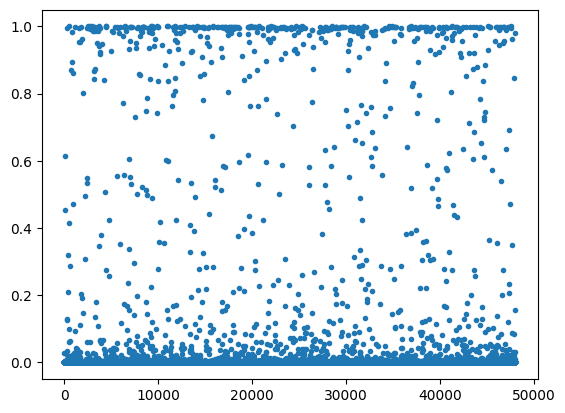

In [101]:
plt.plot(predictions, '.')

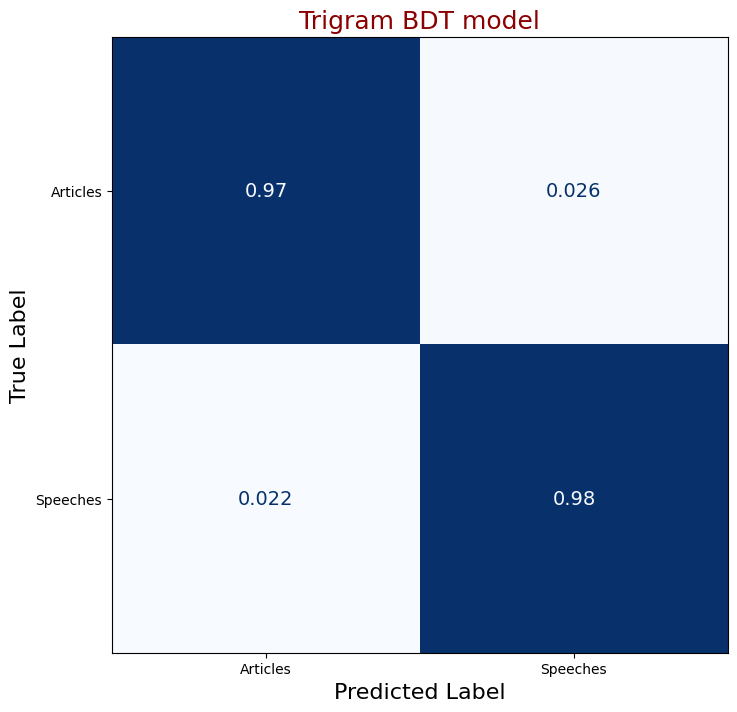

In [131]:
cm = confusion_matrix(data_test_labels, predictions > 0.002, normalize='true')
classes = ["Articles", "Speeches"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax = ax, xticks_rotation=0, cmap=plt.cm.Blues, colorbar=False)
for t in disp.text_.ravel():
    t.set_fontsize(14)
plt.title("Trigram BDT model", fontsize=18, color="darkred")
plt.xlabel("Predicted Label", fontsize=16)
plt.ylabel("True Label", fontsize=16)
plt.savefig("confusion_matrix_speeches.png", dpi=300)
plt.show()

In [116]:
gain = model_binary.feature_importance(importance_type="gain", iteration=model_binary.best_iteration)
gain_idx = np.argsort(gain)[::-1]
data_sort = data_comb[:, gain_idx]

In [33]:
def calculate_tpr_fpr_auc(y_true, y_scores):
    fpr = np.linspace(0, 1, 50000)
    tpr = np.zeros_like(fpr)
    for i in range(10):
        fpr_part, tpr_part, _ = roc_curve(y_true, y_scores[:, i], pos_label=i)
        old_idx = 0
        for j, fpr_subpart in enumerate(fpr_part):
            idx = np.searchsorted(fpr, fpr_subpart)
            tpr[old_idx:idx] += tpr_part[j]
            old_idx = idx
    auc = roc_auc_score(y_true, y_scores, multi_class="ovr", average="macro")
    tpr /= 10
    tpr[-1] = 1
    return tpr, fpr, auc

In [87]:
Used_features = [10, 50, 150, 300, 500, 1500, 2500, 5000, 10000, 15000, 27000]
fpr_comb = []
tpr_comb = []
auc_comb = []
for features in Used_features:
    data_train_red = data_sort[:, :features]
    data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(data_train_red, labels_comb, val_size=0.20, test_size=0.00)
    lgb_train = lgbm.Dataset(data_train, label=data_train_labels)
    lgb_val = lgbm.Dataset(data_val, label=data_val_labels, reference=lgb_train)
    model_binary_red = lgbm.train(params_binary, lgb_train, valid_sets=[lgb_val], valid_names=["val"], num_boost_round=5000, callbacks=[early_stopping(stopping_rounds=100)])
    predictions_red = model_binary_red.predict(data_val, num_iteration=model_binary_red.best_iteration)
    fpr_red, tpr_red, _ = roc_curve(data_val_labels, predictions_red)
    auc_red = roc_auc_score(data_val_labels, predictions_red)
    fpr_comb.append(fpr_red)
    tpr_comb.append(tpr_red)
    auc_comb.append(auc_red)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[205]	val's binary_logloss: 0.0644306
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[272]	val's binary_logloss: 0.0564223
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[295]	val's binary_logloss: 0.056883
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[280]	val's binary_logloss: 0.05756
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[321]	val's binary_logloss: 0.0596933
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[375]	val's binary_logloss: 0.0618195
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[395]	val's binary_logloss: 0.0581123
Training until validation scores don't improve for 100 rou

In [117]:
np.savetxt("txt_files/speeches_sort_idx.txt", gain_idx, delimiter="\n", fmt="%d")

In [88]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

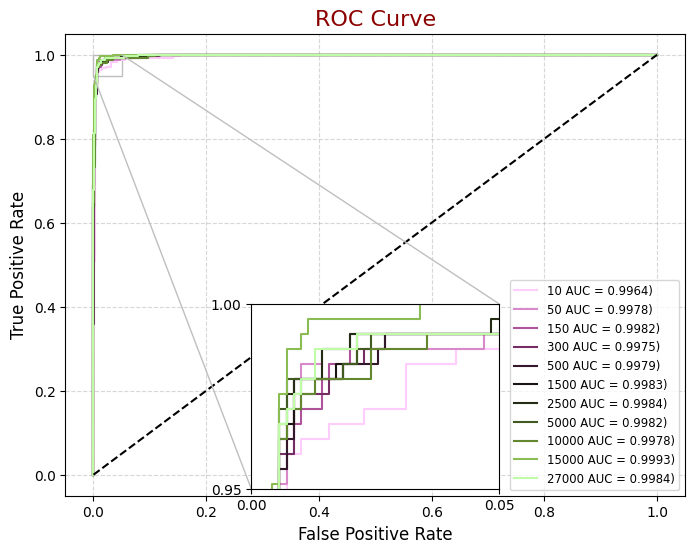

In [92]:
fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.cm.vanimo(np.linspace(0, 1, len(Used_features)))

axins = inset_axes(ax, width="40%", height="40%", loc="lower center")
for i in range(len(Used_features)):
    ax.plot(fpr_comb[i], tpr_comb[i], label=f"{Used_features[i]} AUC = {auc_comb[i]:.4f})", color=cmap[i])
    axins.plot(fpr_comb[i], tpr_comb[i], label=f"{Used_features[i]} AUC = {auc_comb[i]:.4f})", color=cmap[i])
axins.set_xlim(0.00, 0.05)
axins.set_ylim(0.95, 1.00)
axins.set_xticks(np.arange(0.00, 0.06, 0.05))
axins.set_yticks(np.arange(0.95, 1.01, 0.05))
axins.grid(True, linestyle="--", alpha=0.5)
mark_inset(ax, axins, loc1=1, loc2=3, fc="none", ec="0.75")


ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve", fontsize=16, color="darkred")
ax.legend(loc="lower right", fontsize="small")
ax.grid(True, linestyle="--", alpha=0.5)    
plt.savefig("ROC_Curve_Sermons.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
def data_time_split(data, labels, split_year):
    data_early = data[labels < split_year]
    labels_early = labels[labels < split_year]
    data_late = data[labels >= split_year]
    labels_late = labels[labels >= split_year]
    return data_early, labels_early, data_late, labels_late

In [11]:
data_train, labels_train, data_val, labels_val, data_test, labels_test = train_val_test_split(data_scaled, dates)
data_train_early, labels_train_early, data_train_temp, labels_train_temp = data_time_split(data_train, labels_train, 1800)
data_train_middle, labels_train_middle, data_train_late, labels_train_late = data_time_split(data_train_temp, labels_train_temp, 2000)
data_val_early, labels_val_early, data_val_temp, labels_val_temp = data_time_split(data_val, labels_val, 1800)
data_val_middle, labels_val_middle, data_val_late, labels_val_late = data_time_split(data_val_temp, labels_val_temp, 2000)

In [ ]:
params_binary = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "num_leaves": 100,
    "min_data_in_leaf": 5,
    "learning_rate": 0.02,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

params_regression = {
    "objective": "regression",
    "boosting_type": "gbdt",
    "num_leaves": 100,
    "min_data_in_leaf": 5,
    "learning_rate": 0.02,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

In [13]:
labels_train_class = labels_train
labels_train_class[labels_train_class < 1800] = 0
labels_train_class[(labels_train_class >= 1800) & (labels_train_class < 2000)] = 1
labels_train_class[labels_train_class >= 2000] = 2
labels_val_class = labels_val
labels_val_class[labels_val_class < 1800] = 0
labels_val_class[(labels_val_class >= 1800) & (labels_val_class < 2000)] = 1
labels_val_class[labels_val_class >= 2000] = 2

In [18]:
lgb_train = lgbm.Dataset(data_train, label=labels_train_class)
lgb_val = lgbm.Dataset(data_val, label=labels_val_class, reference=lgb_train)
model_multiclass = lgbm.train(params_class, lgb_train, valid_sets=[lgb_val], valid_names=["val"], num_boost_round=1000, callbacks=[early_stopping(stopping_rounds=50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[267]	val's multi_logloss: 0.28559


In [19]:
lgb_train_reg1 = lgbm.Dataset(data_train_early, label=labels_train_early)
lgb_val_reg1 = lgbm.Dataset(data_val_early, label=labels_val_early, reference=lgb_train_reg1)
model_regression_early = lgbm.train(params_regression, lgb_train_reg1, valid_sets=[lgb_val_reg1], valid_names=["val"], num_boost_round=1000, callbacks=[early_stopping(stopping_rounds=50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[120]	val's l2: 8766.99


In [20]:
lgb_train_reg2 = lgbm.Dataset(data_train_middle, label=labels_train_middle)
lgb_val_reg2 = lgbm.Dataset(data_val_middle, label=labels_val_middle, reference=lgb_train_reg2)
model_regression_middle = lgbm.train(params_regression, lgb_train_reg2, valid_sets=[lgb_val_reg2], valid_names=["val"], num_boost_round=1000, callbacks=[early_stopping(stopping_rounds=50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[798]	val's l2: 758.523


In [21]:
lgb_train_reg3 = lgbm.Dataset(data_train_late, label=labels_train_late)
lgb_val_reg3 = lgbm.Dataset(data_val_late, label=labels_val_late, reference=lgb_train_reg3)
model_regression_late = lgbm.train(params_regression, lgb_train_reg3, valid_sets=[lgb_val_reg3], valid_names=["val"], num_boost_round=1000, callbacks=[early_stopping(stopping_rounds=50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[772]	val's l2: 25.4075


In [25]:
test_pred_multiclass = model_multiclass.predict(data_test, num_iteration=model_multiclass.best_iteration)

In [30]:
test_classified = np.argmax(test_pred_multiclass, axis=1)
test_early = data_test[test_classified == 0]
test_middle = data_test[test_classified == 1]
test_late = data_test[test_classified == 2]
labels_test_early = labels_test[test_classified == 0]
labels_test_middle = labels_test[test_classified == 1]
labels_test_late = labels_test[test_classified == 2]

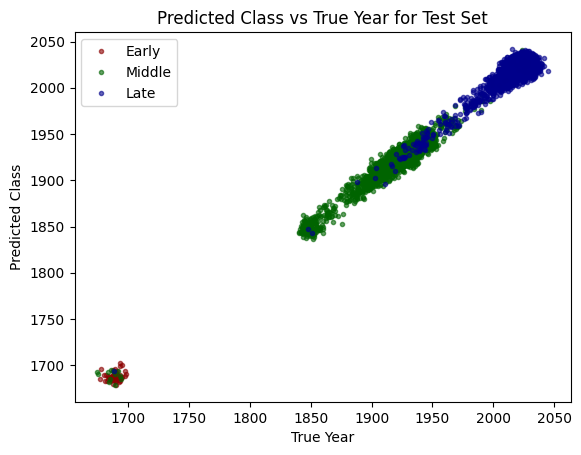

In [55]:
noise_y = np.random.normal(0, 5, size=test_classified.shape)  # Add small noise for better visualization
noise_x = np.random.normal(0, 5, size=test_classified.shape)  # Add small noise for better visualization
plt.plot(labels_test[test_classified == 0] + noise_x[test_classified == 0], labels_test[test_classified == 0] + noise_y[test_classified == 0], ".", label="Early", color="darkred", alpha=0.6)
plt.plot(labels_test[test_classified == 1] + noise_x[test_classified == 1], labels_test[test_classified == 1] + noise_y[test_classified == 1], ".", label="Middle", color="darkgreen", alpha=0.6)
plt.plot(labels_test[test_classified == 2] + noise_x[test_classified == 2], labels_test[test_classified == 2] + noise_y[test_classified == 2], ".", label="Late", color="darkblue", alpha=0.6)
plt.xlabel("True Year")
plt.ylabel("Predicted Class")
plt.title("Predicted Class vs True Year for Test Set")
plt.legend()
plt.show()

In [57]:
test_pred_early = model_regression_early.predict(test_early, num_iteration=model_regression_early.best_iteration)
test_pred_middle = model_regression_middle.predict(test_middle, num_iteration=model_regression_middle.best_iteration)
test_pred_late = model_regression_late.predict(test_late, num_iteration=model_regression_late.best_iteration)
test_pred_combined = np.concatenate((test_pred_early, test_pred_middle, test_pred_late))
labels_test_combined = np.concatenate((labels_test_early, labels_test_middle, labels_test_late))

In [41]:
labels_test_late.min()

np.float64(1688.0)

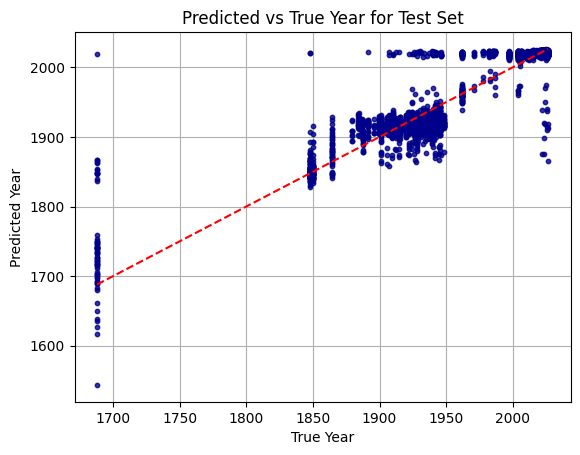

In [66]:
plt.scatter(labels_test_combined, test_pred_combined, alpha=0.8, s=10, color="darkblue", zorder=2)
plt.plot([labels_test_combined.min(), labels_test_combined.max()], [labels_test_combined.min(), labels_test_combined.max()], "r--")
plt.xlabel("True Year")
plt.ylabel("Predicted Year")
plt.title("Predicted vs True Year for Test Set")
plt.grid()
plt.show()

In [69]:
train_data = data_scaled[:int(0.8*len(data_scaled))]
train_labels = labels_scaled[:int(0.8*len(labels_scaled))]
val_data = data_scaled[int(0.8*len(data_scaled)):int(0.95*len(data_scaled))]
val_labels = labels_scaled[int(0.8*len(labels_scaled)):int(0.95*len(labels_scaled))]
test_data = data_scaled[int(0.95*len(data_scaled)):]
test_labels = labels_scaled[int(0.95*len(labels_scaled)):]
lgb_train = lgbm.Dataset(train_data, label=train_labels)
lgb_val = lgbm.Dataset(val_data, label=val_labels, reference=lgb_train)
model = lgbm.train(params, lgb_train, valid_sets=[lgb_train, lgb_val], num_boost_round=1000, callbacks=[early_stopping(50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[764]	training's binary_logloss: 0.0302138	valid_1's binary_logloss: 0.177644


In [70]:
fpr_trigon_filtered, tpr_trigon_filtered, _ = roc_curve(test_labels, model.predict(test_data))

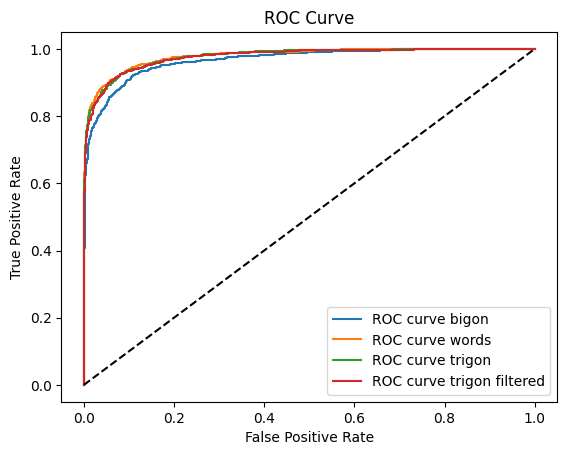

In [71]:
plt.plot(fpr_bigon, tpr_bigon, label="ROC curve bigon")
plt.plot(fpr_words, tpr_words, label="ROC curve words")
plt.plot(fpr_trigon, tpr_trigon, label="ROC curve trigon")
plt.plot(fpr_trigon_filtered, tpr_trigon_filtered, label="ROC curve trigon filtered")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

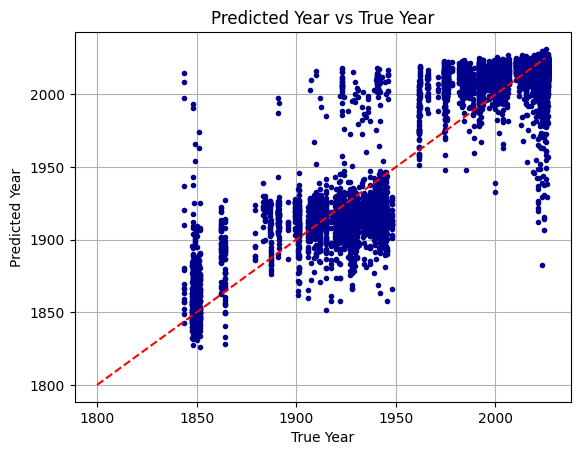

In [12]:
plt.plot(test_labels, model.predict(test_data), ".", color="darkblue")
plt.plot(val_labels, model.predict(val_data), ".", color="darkblue")
plt.xlabel("True Year")
plt.ylabel("Predicted Year")
plt.title("Predicted Year vs True Year")
plt.plot([1800, 2025], [1800, 2025], "r--")
plt.grid()

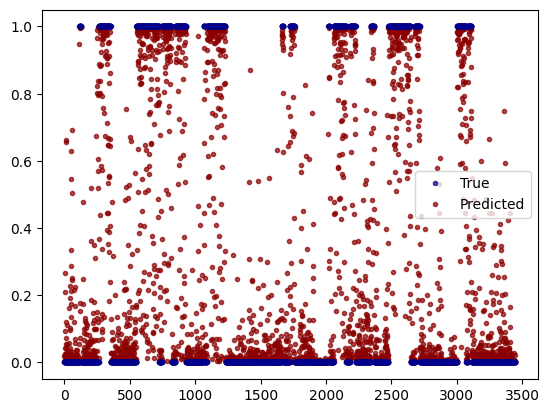

In [25]:
plt.plot(test_labels, '.', label="True", alpha=0.7, color="darkblue", zorder=3)
plt.plot(model.predict(test_data), '.', label="Predicted", alpha=0.7, color="darkred")
plt.legend()
plt.show()

In [16]:
idx = np.argsort(model.feature_importance(importance_type="gain"))[::-1]
print(np.array(bigons)[idx][:50])

['aa' 'å ' 'de' 'a ' 'øi' 'år' 'kj' 'ei' 'ee' 'qa' 'r ' 'ae' 'ej' 'gj'
 'e ' 'jø' 'kv' ' p' 'gø' 'ig' 'jo' 'ii' 'nd' 'lk' 's ' 'på' 'hr' 'do'
 'øj' ' h' 'ls' 'hi' 'i ' 'th' 'er' 'gu' ' d' 'hv' 'ju' ' a' 'ar' 'en'
 't ' 'in' 'vj' 'iø' 'et' 'el' 'rr' ' g']


In [ ]:
#np.savetxt("txt_files/words_ranked_years.txt", words[idx], delimiter="\n", fmt="%s")

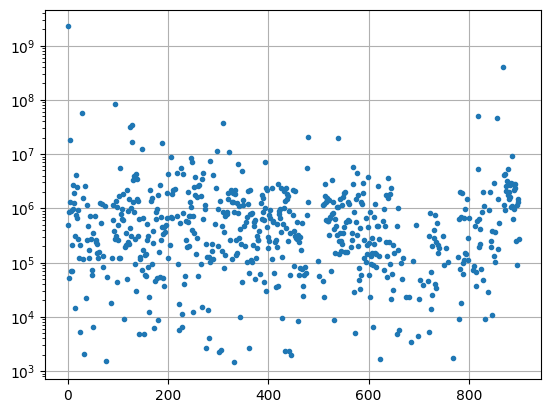

In [17]:
plt.plot(model.feature_importance(importance_type="gain"), ".")
plt.yscale("log")
plt.grid()

In [6]:
test_speech = open("test.txt", "r").read()
test_speech_data = bf.convert_to_data(test_speech, chars)

In [7]:
model.predict([test_speech_data])

array([23.64302537])

In [27]:
np.mean(labels)

np.float64(1993.833620919064)

In [13]:
model.predict(test_data)

array([ -43.45949295,  -55.31170448,  -41.86957323,  -61.60097825,
        -32.50387642,   15.8978201 ,   26.50305802,   10.3817101 ,
         23.54973952,  -75.1508267 ,   25.89405299,   24.26719992,
         19.27546165,   21.88278845,   18.91638827,   23.53752988,
         31.7233499 ,   15.75853587, -122.08753968,   23.71300754,
         18.44896129,   23.31839616,   16.0102125 ,   21.19210292,
          5.51567146,   21.60828215,   25.42972843,   25.01657786,
         26.29343679,   23.92454995,   26.18655454,   23.69506529,
         10.65264355,   24.38383314,   10.64566627,   23.69690549,
         23.34904098,   16.09072231,   22.8684581 ,   23.79729154,
         20.85383015,   24.04316806,   24.12764137,   23.89440954,
         16.31669968,   10.35891703,   20.33592943,   19.16334952,
         20.64140921,   24.11454124,   28.26948276,   25.23077268,
         26.1321853 ,   24.29464827,   17.40945138,   18.31327158,
          7.73357783,   16.13740252,   18.38265718,   15.15270

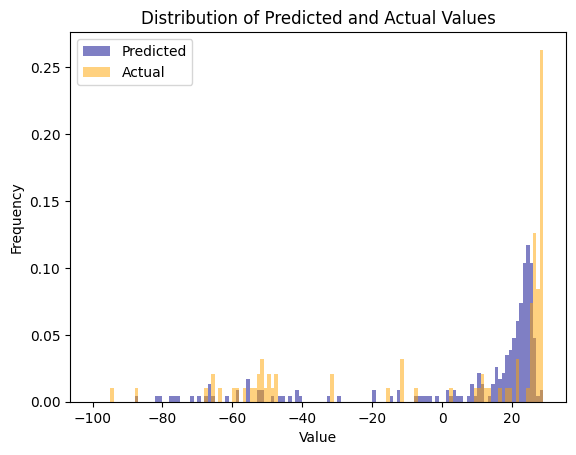

In [25]:
plt.hist(model.predict(test_data), bins=np.arange(-100, 30, 1), label="Predicted", color="darkblue", alpha=0.5, density=True)
plt.hist(test_labels, bins=np.arange(-100, 30, 1), label="Actual", color="orange", alpha=0.5, density=True)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted and Actual Values")
plt.legend()
plt.show()

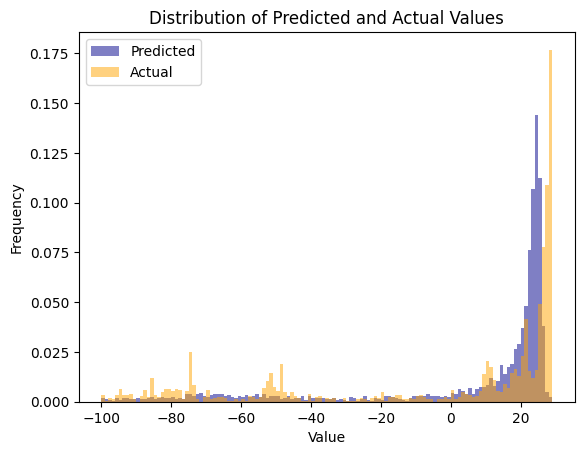

In [26]:
plt.hist(model.predict(train_data), bins=np.arange(-100, 30, 1), label="Predicted", color="darkblue", alpha=0.5, density=True)
plt.hist(train_labels, bins=np.arange(-100, 30, 1), label="Actual", color="orange", alpha=0.5, density=True)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted and Actual Values")
plt.legend()
plt.show()